In [1]:
import os
import h5py

import sys
from pathlib import Path

project_root = Path().resolve().parent
src_path = project_root / "src"

sys.path.append(str(src_path))

from training.fno_training import EmulatorFNO
from training.DiffusionModel import Diffusion
from fno.fno_2D_classifier import FNO2D_classifier
from training.dataset_manager import DatasetManagerMulti

import torch
import yaml
import matplotlib.pyplot as plt
import numpy as np

from tqdm import tqdm

import time

In [2]:
device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {device}")

Using device: mps


In [3]:
model_rep_path = project_root / "runs_mesu" / "diffusion1"
with open(model_rep_path / "config.yaml", "r") as f:
    args = yaml.safe_load(f)

# Data importation

In [4]:
data_path = project_root / "data"
train_path = data_path / "train_traj"
test_path = data_path / "test_traj"

In [5]:
train_dataset = DatasetManagerMulti(data_rep=data_path,
                                    exp_dir=args["exp_dir"],
                                    seq_length=args["seq_length"],
                                    batch_size=args["batch_size"],
                                    num_workers=args["num_workers"],
                                    ratio=args["ratio"],
                                    stride=args["stride"],
                                    diffusion=True)
                

In [ ]:
len(train_dataset.training_dataset)

# Model importation

In [6]:

model = FNO2D_classifier(input_dim=args["input_dim"],
                        output_dim=args["output_dim"],
                        modes_x=args["k_max_x"],
                        modes_y=args["k_max_y"],
                        width=args["width"],
                        l=args["l"],
                        n_layer=args["n_fourier_layer"],
                        hidden_proj=args["hidden_proj"],
                        mlp=args["mlp"],
                        layers_mlp=args["layers_mlp"],
                        class_mlp_layers=args["class_mlp_layers"],
                        n_cat=args["timesteps"],
                        device=device
                        )

diffusion_model = Diffusion(model,
                            timesteps=args["timesteps"])

diffusion_model.load_state_dict(torch.load(model_rep_path / "model_weights/min_train_loss.pth", map_location=device)["model_state_dict"])
diffusion_model = diffusion_model.to(device)

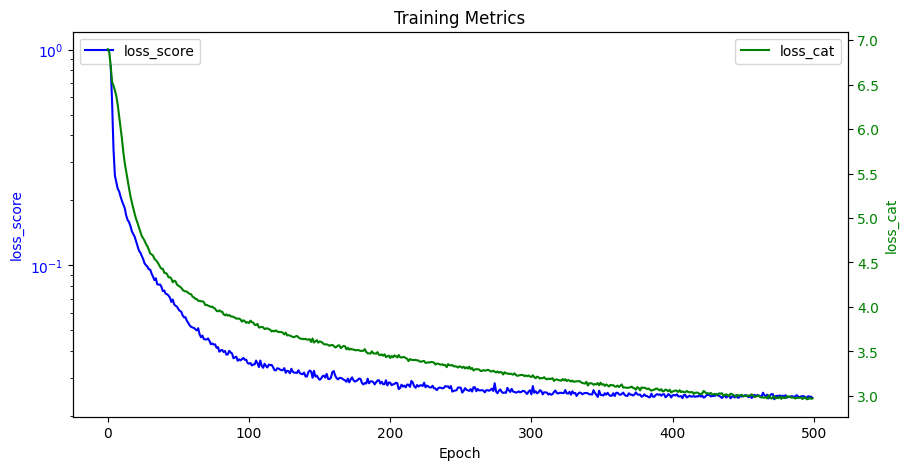

In [7]:
with open(model_rep_path / "logs/metrics.csv", "r") as f:
    lines = f.readlines()

header = lines[0].strip().split(",")
data = np.array([[float(v) for v in line.strip().split(",")] for line in lines[1:]])

epochs = np.arange(data.shape[0])

# --- Tracer ---
fig, ax_left = plt.subplots(figsize=(10,5))

# Couleur axe gauche
color_left = "blue"
ax_left.plot(epochs, data[:,2], label=header[2], color=color_left)
ax_left.set_yscale("log")
ax_left.set_xlabel("Epoch")
ax_left.set_ylabel(header[2], color=color_left)
ax_left.tick_params(axis='y', labelcolor=color_left)
ax_left.legend(loc="upper left")

# Couleur axe droit
color_right = "green"
ax_right = ax_left.twinx()
ax_right.plot(epochs, data[:,3], label=header[3], color=color_right)
ax_right.set_ylabel(header[3], color=color_right)
ax_right.tick_params(axis='y', labelcolor=color_right)
ax_right.legend(loc="upper right")

plt.title("Training Metrics")
plt.show();


# Classifier test

In [8]:
def test_classifier():
    batch = next(iter(train_dataset.training_loader))
    train_images = batch.to(device)
    predicted_distribution = torch.zeros((args["timesteps"], args["timesteps"]), device=device)

    model.eval()
    with torch.no_grad():
        for aa in tqdm(range(args["timesteps"])):
            noise = torch.randn_like(train_images)
            noise_categories = (torch.ones(len(train_images), device=device) * aa).to(torch.int64)
            noised_imgs = diffusion_model._forward_diffusion(train_images, noise_categories, noise)
            _, pred_noise_level = diffusion_model.model(noised_imgs, True)
            predicted_distribution[aa] += torch.nn.Softmax(-1)(pred_noise_level).mean(dim=0)

    predicted_distribution = predicted_distribution.cpu()
    dist_figure = plt.figure()
    plt.imshow(predicted_distribution, vmin=0, vmax=0.2, cmap='gist_heat_r')
    plt.colorbar()
    plt.xlabel("Predicted noise level")
    plt.ylabel("True noise level")

    return predicted_distribution

predicted_distribution = test_classifier()


 14%|█▍        | 143/1000 [00:11<01:10, 12.16it/s]


RuntimeError: MPS backend out of memory (MPS allocated: 1.08 GiB, other allocations: 44.86 GiB, max allowed: 45.90 GiB). Tried to allocate 66.00 MiB on private pool. Use PYTORCH_MPS_HIGH_WATERMARK_RATIO=0.0 to disable upper limit for memory allocations (may cause system failure).

In [9]:
predicted_distribution = predicted_distribution.cpu()
dist_figure = plt.figure()
plt.imshow(predicted_distribution, vmin=0, vmax=0.1, cmap='gist_heat_r')
plt.colorbar()
plt.xlabel("Predicted noise level")
plt.ylabel("True noise level");

NameError: name 'predicted_distribution' is not defined

In [10]:
predicted_cat = torch.argmax(predicted_distribution, axis=1)
plt.plot(torch.arange(1000),predicted_cat);

NameError: name 'predicted_distribution' is not defined

# Test sample

In [11]:
def vorticity(velocity_field):
    u = velocity_field[..., 0]
    v = velocity_field[..., 1]
    
    du_dy = np.gradient(u, axis=-1)
    dv_dx = np.gradient(v, axis=-2)
    
    return dv_dx - du_dy

Sampling: 100%|██████████| 1000/1000 [01:04<00:00, 15.58it/s]


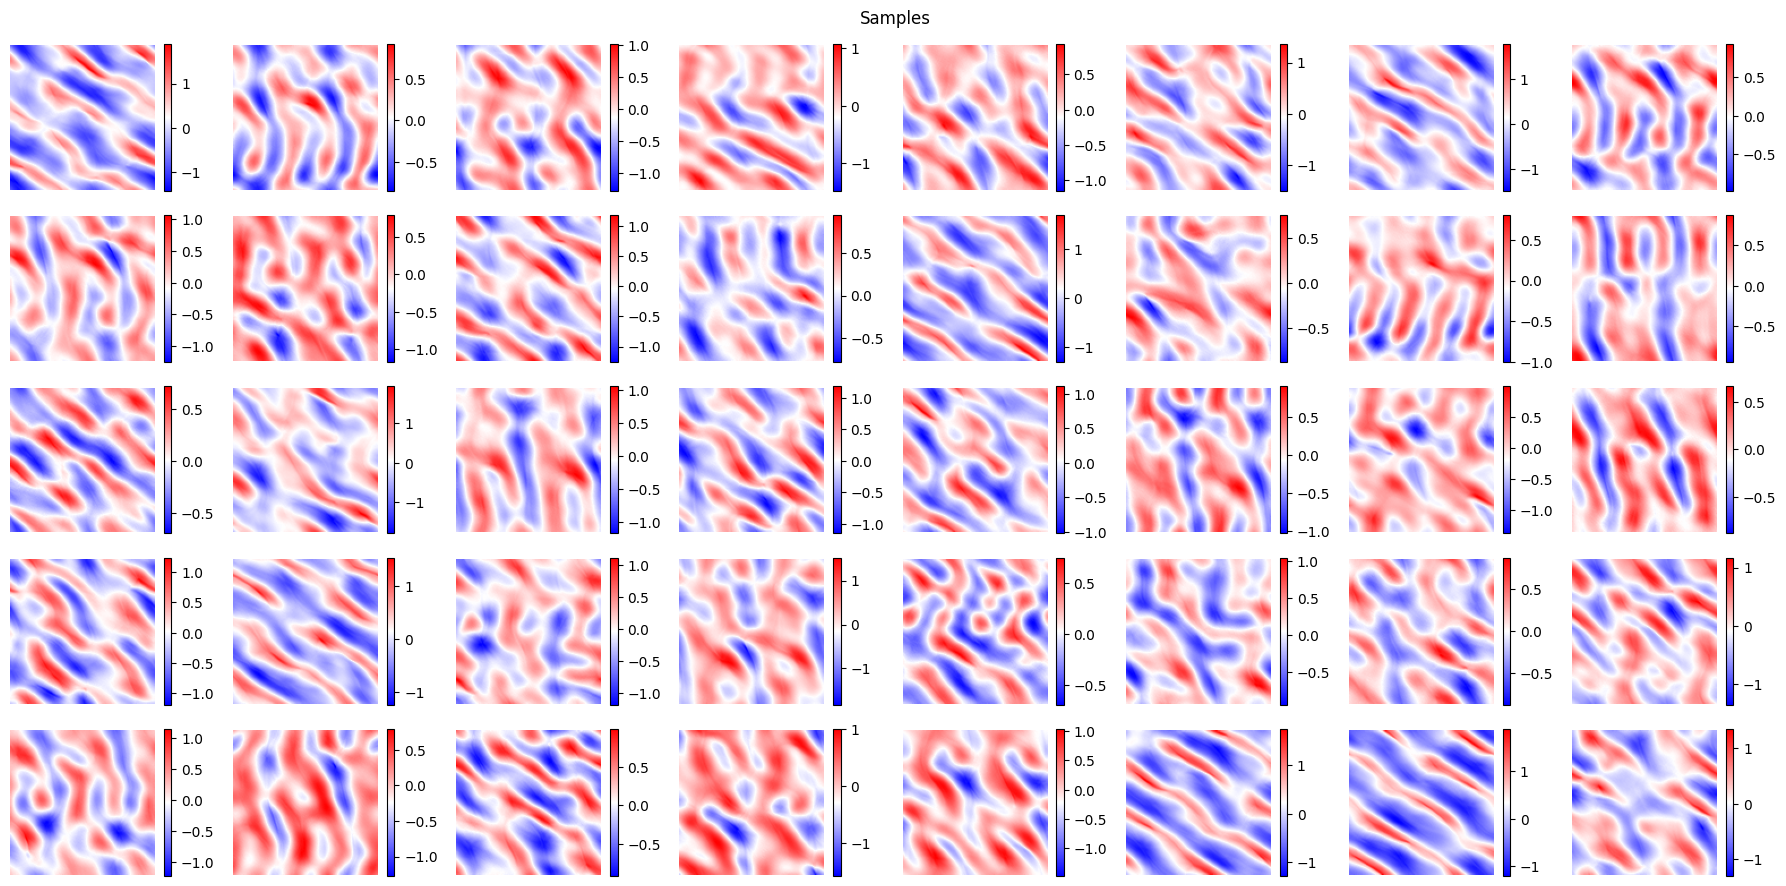

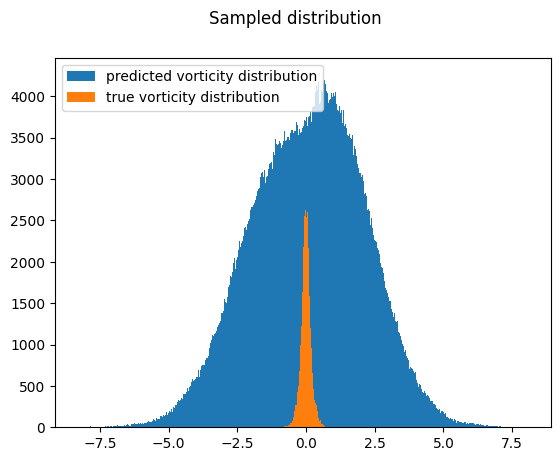

In [12]:
import seaborn as sns

def test_samples():
    ####### Classifier test
    diffusion_model.eval()
    with torch.no_grad():
        samples = diffusion_model.sampling(40, 128, device=device)

    if samples.isnan().any():
        print("Samples have nans, ignoring plot routines")
        return

    samples = samples.cpu().numpy()

    vorticity_sampled = vorticity(samples)
    
    samples_fig=plt.figure(figsize=(18, 9))
    plt.suptitle("Samples")
    for i in range(40):
        plt.subplot(5, 8, 1 + i)
        plt.axis('off')
        plt.imshow(vorticity_sampled[i].squeeze(), cmap='bwr')
        plt.colorbar()
    plt.tight_layout()


    
    hist_figure = plt.figure()
    plt.suptitle("Sampled distribution")
    plt.hist(samples.flatten(),bins=1000, label='predicted vorticity distribution')
    batch_train = next(iter(train_dataset.training_loader))
    vort_train = vorticity(batch_train)
    plt.hist(vort_train.flatten(), bins=1000, label='true vorticity distribution')
    plt.legend();

    return samples
    
samples = test_samples()


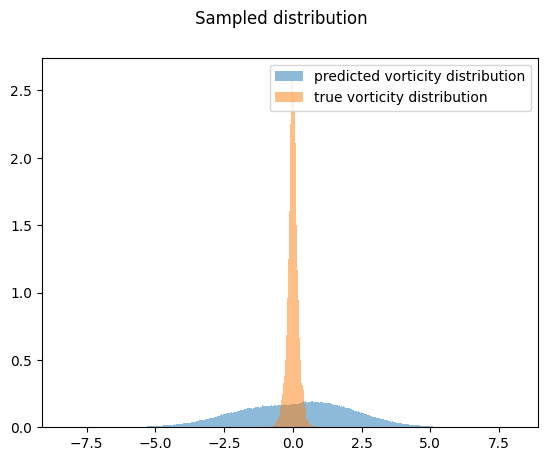

In [13]:
hist_figure = plt.figure()
plt.suptitle("Sampled distribution")
plt.hist(samples.flatten(),bins=1000, label='predicted vorticity distribution', density=True, alpha=0.5)
batch_train = next(iter(train_dataset.training_loader))
vort_train = vorticity(batch_train)
plt.hist(vort_train.flatten(), bins=1000, label='true vorticity distribution', density=True, alpha=0.5)
plt.legend();

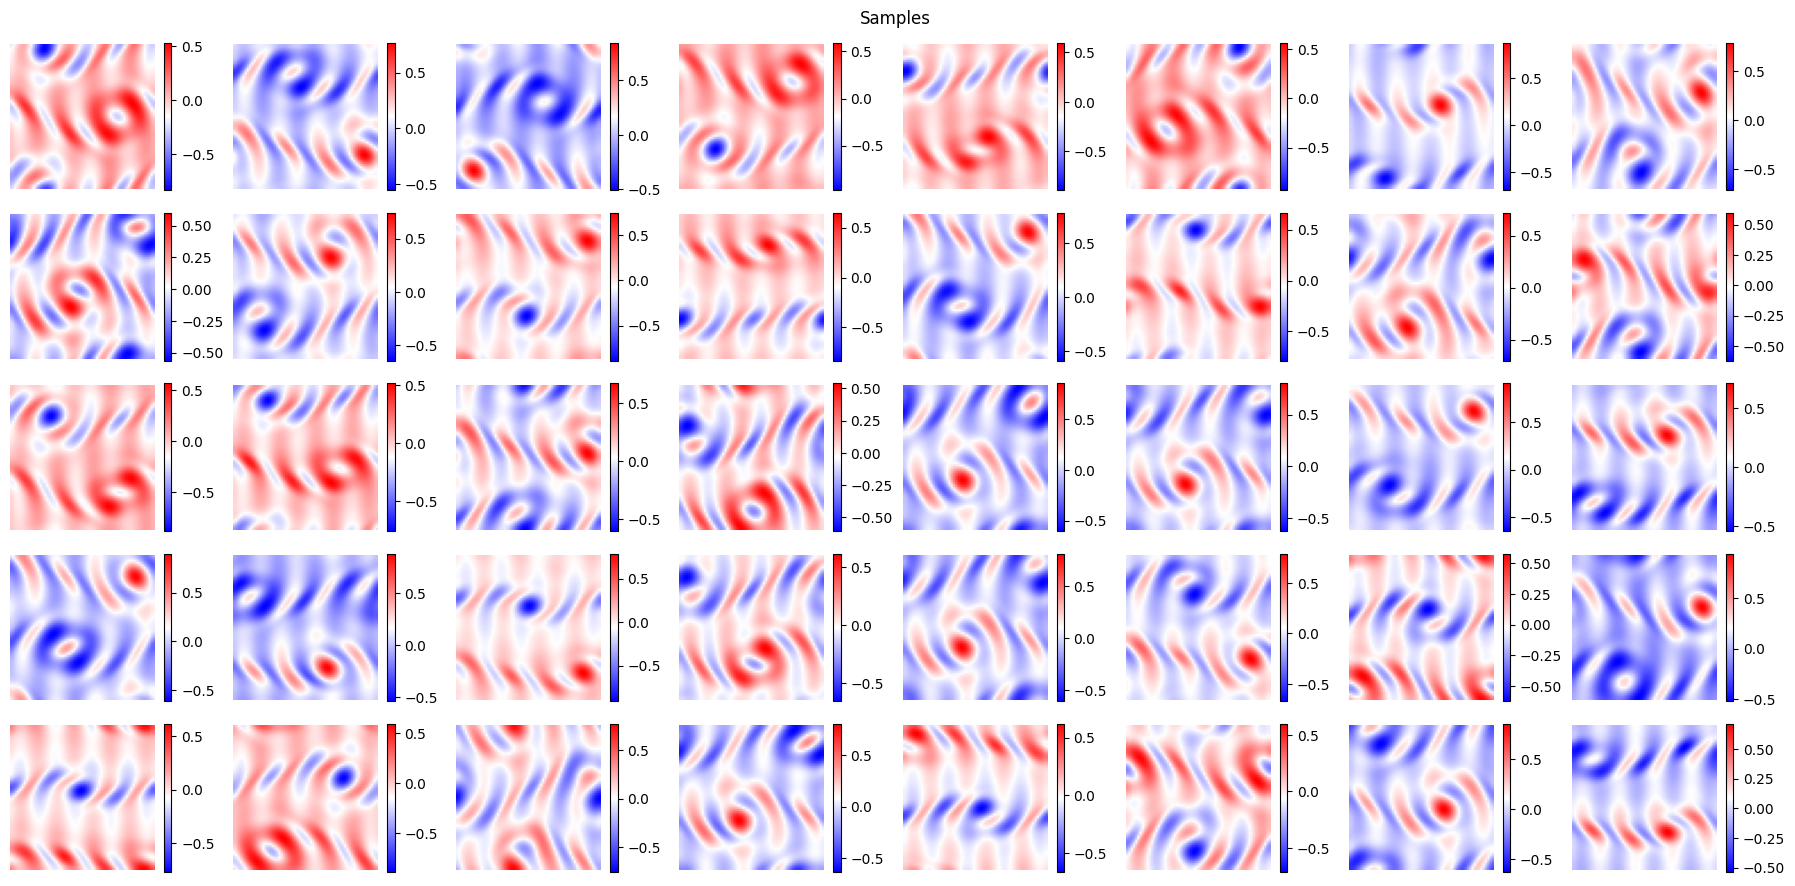

In [14]:
batch_train = next(iter(train_dataset.training_loader))
vort_train = vorticity(batch_train)

samples_fig=plt.figure(figsize=(18, 9))
plt.suptitle("Samples")
for i in range(40):
    plt.subplot(5, 8, 1 + i)
    plt.axis('off')
    plt.imshow(vort_train[i].squeeze(), cmap='bwr')
    plt.colorbar()
plt.tight_layout()

# Model simulation Emulator + thermalizer

In [15]:
emulator_rep_path = project_root / "runs_mesu" / "exp3"

with open(emulator_rep_path / "config.yaml", "r") as f:
    args = yaml.safe_load(f)

emulator = EmulatorFNO(input_dim=args["input_dim"],
                    output_dim=args["output_dim"],
                    modes_x=args["k_max_x"],
                    modes_y=args["k_max_y"],
                    width=args["width"],
                    l=args["l"],
                    n_layer=args["n_fourier_layer"],
                    hidden_proj=args["hidden_proj"],
                    mlp=args["mlp"],
                    layers_mlp=args["layers_mlp"],
                    tau=args["tau"],
                    device=device)

emulator.load_state_dict(torch.load(emulator_rep_path / "model_weights/min_test_loss.pth", map_location=device)["model_state_dict"])
emulator = emulator.to(device)

## In distribution

In [16]:
data_path = project_root / "data" / "kolmogorov" / "Re34"
train_path = data_path / "train_traj"
test_path = data_path / "test_traj"

with h5py.File(train_path / "sim1.h5", "r") as f:
    sim_train = f["velocity_field"][:]
    print("sim_train, nk=", f["nk"][()])
with h5py.File(test_path / "sim1.h5", "r") as f:
    sim_test = f["velocity_field"][:]  
    print("sim_test, nk=", f["nk"][()])  

sim_train, nk= 16
sim_test, nk= 8


In [17]:
s_stop = 3
s_init = 7

def compute_next_step(x_t, tau=None, trace=False):
    
    tracker = {'count_correction': 0}
    if tau is None:
        tau = emulator.tau
    current = x_t.to(torch.float32).to(device).unsqueeze(0)
    x_t = current + emulator(current) + tau*torch.randn_like(x_t, device=device)
    _, t = diffusion_model.model(x_t)
    t = torch.nn.Softmax(-1)(t)
    t = torch.argmax(t)
    if t > s_init:
        eps = torch.randn_like(x_t)
        if trace:
            tracker['count_correction'] += 1
            tracker['snapshots_to_correct'] = x_t
            tracker['noise_levels']= t
        x_t = diffusion_model._forward_diffusion(x_t, t, eps)
        for s in range(t, s_stop-1,-1):
            z = torch.randn_like(x_t)
            s_tensor = torch.full((x_t.shape[0],), s, dtype=torch.long, device=x_t.device)
            x_t = diffusion_model._reverse_diffusion(x_t, s_tensor, z)

        tracker['snapshots_corrected'] = x_t
    
    return x_t, tracker

starting_point = torch.from_numpy(sim_train)[0].unsqueeze(0).to(torch.float32).to(device)
starting_point.shape

torch.Size([1, 128, 128, 2])

In [ ]:
predict_horizon = 6000 - 1

In [ ]:
with torch.no_grad():
    simulation_fno = emulator.predict_sequence(starting_point, pred_horizon=predict_horizon).cpu().numpy()

In [ ]:
simulation_fno = simulation_fno.squeeze()

In [ ]:
predictions = torch.empty((predict_horizon+1, 128,128, 2))

In [ ]:
predictions[0] = starting_point[0]
with torch.no_grad():
    tracker = {'count_correction': 0,
               'snapshots_to_correct': [],
               'snapshots_corrected': [],
               'noise_levels': []}
    for i in tqdm(range(predict_horizon-1)):
        predictions[i+1], track = compute_next_step(predictions[i], trace=True, tau=0)
        if track['count_correction'] == 1:
            tracker['count_correction'] +=1
            tracker['snapshots_to_correct'].append(track['snapshots_to_correct'])
            tracker['snapshots_corrected'].append(track['snapshots_corrected'])
            tracker['noise_levels'].append(track['noise_levels'])

In [ ]:
print("Number of corrections: ", tracker['count_correction'])

In [ ]:
fig, ax = plt.subplots(2, 8, figsize=(18, 5))

dt = 0.1
snapshots_to_correct = np.concat([snap.cpu().numpy() for snap in tracker["snapshots_to_correct"]], axis=0)
snapshots_corrected = np.concat([snap.cpu().numpy() for snap in tracker["snapshots_corrected"]], axis=0)
print(snapshots_corrected.shape)
vmin, vmax = vorticity(snapshots_to_correct).min(), vorticity(snapshots_to_correct).max()

for j in range(8):
    d = 1 * j
    ax[0, j].pcolormesh(vorticity(snapshots_to_correct[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[1, j].pcolormesh(vorticity(snapshots_corrected[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[0, j].set_title(f"t={d*dt}")
    for i in range(2):
        ax[i, j].axis('off')

# labels de lignes (coordonnées figure)
row_labels = [
    "FNO emulator",
    "Thermalized"
]

y_positions = [0.78, 0.22]

for label, y in zip(row_labels, y_positions):
    fig.text(0.0, y, label, va='center', ha='center', rotation=0, fontsize=20)

plt.tight_layout(rect=[0.06, 0, 1, 1])


In [ ]:
noise_levels = np.array([nl.cpu().numpy() for nl in tracker["noise_levels"]])
bins = np.arange(noise_levels.min() - 0.5,
                 noise_levels.max() + 1.5,
                 1)

plt.figure()
plt.hist(noise_levels, bins=bins)
plt.xticks(np.arange(noise_levels.min(), noise_levels.max() + 1))
plt.xlabel("Noise level")
plt.ylabel("Count")
plt.title("Distribution of Noise Levels")
plt.grid(axis='y', alpha=0.3)
plt.show();

### Results

In [ ]:
def vorticity(velocity_field):
    u = velocity_field[..., 0]
    v = velocity_field[..., 1]
    
    du_dy = np.gradient(u, axis=-1)
    dv_dx = np.gradient(v, axis=-2)
    
    return dv_dx - du_dy

#### Vorticity field visualisation

In [ ]:
fig, ax = plt.subplots(3, 8, figsize=(18, 8))

dt = 0.1
vmin, vmax = vorticity(sim_train).min(), vorticity(sim_train).max()

for j in range(8):
    d = 50 * j
    ax[0, j].pcolormesh(vorticity(sim_train[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[1, j].pcolormesh(vorticity(simulation_fno[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[2, j].pcolormesh(vorticity(predictions[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[0, j].set_title(f"t={d*dt}")
    for i in range(3):
        ax[i, j].axis('off')

# labels de lignes (coordonnées figure)
row_labels = [
    "Truth",
    "FNO emulator",
    "FNO emulator\n + FNO thermalizer"
]

y_positions = [0.78, 0.50, 0.22]

for label, y in zip(row_labels, y_positions):
    fig.text(0.0, y, label, va='center', ha='center', rotation=0, fontsize=20)

plt.tight_layout(rect=[0.06, 0, 1, 1])


In [ ]:
fig, ax = plt.subplots(3, 8, figsize=(18, 8))

dt = 0.1
vmin, vmax = vorticity(sim_train).min(), vorticity(sim_train).max()

for j in range(8):
    d = 1000 + 200*j
    ax[0, j].pcolormesh(vorticity(sim_train[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[1, j].pcolormesh(vorticity(simulation_fno[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[2, j].pcolormesh(vorticity(predictions[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[0, j].set_title(f"t={d*dt}")
    for i in range(3):
        ax[i, j].axis('off')

# labels de lignes (coordonnées figure)
row_labels = [
    "Truth",
    "FNO emulator",
    "FNO emulator\n + FNO thermalizer"
]

y_positions = [0.78, 0.50, 0.22]

for label, y in zip(row_labels, y_positions):
    fig.text(0.0, y, label, va='center', ha='center', rotation=0, fontsize=20)

plt.tight_layout(rect=[0.06, 0, 1, 1])


In [ ]:
fig, ax = plt.subplots(3, 8, figsize=(18, 8))

dt = 0.1
vmin, vmax = vorticity(sim_train).min(), vorticity(sim_train).max()

for j in range(8):
    d = 2500 + 400*j
    ax[0, j].pcolormesh(vorticity(sim_train[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[1, j].pcolormesh(vorticity(simulation_fno[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[2, j].pcolormesh(vorticity(predictions[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[0, j].set_title(f"t={d*dt}", fontsize=20)
    for i in range(3):
        ax[i, j].axis('off')

# labels de lignes (coordonnées figure)
row_labels = [
    "Ground Truth",
    "Autoregressive\n simulator",
    "Autoregressive\n simulator + diffusion"
]

y_positions = [0.78, 0.50, 0.2]

for label, y in zip(row_labels, y_positions):
    fig.text(-0.04, y, label, va='center', ha='center', rotation=0, fontsize=24)

plt.tight_layout(rect=[0.06, 0, 1, 1])


In [ ]:
fig, ax = plt.subplots(3, 8, figsize=(18, 8))

dt = 0.1
vmin, vmax = vorticity(sim_train).min(), vorticity(sim_train).max()

for j in range(8):
    d = 0 + 800*j
    ax[0, j].pcolormesh(vorticity(sim_train[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[1, j].pcolormesh(vorticity(simulation_fno[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[2, j].pcolormesh(vorticity(predictions[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[0, j].set_title(f"t={d*dt}", fontsize=20)
    for i in range(3):
        ax[i, j].axis('off')

# labels de lignes (coordonnées figure)
row_labels = [
    "Ground Truth",
    "Autoregressive\n simulator",
    "Autoregressive\n simulator + diffusion"
]

y_positions = [0.78, 0.50, 0.2]

for label, y in zip(row_labels, y_positions):
    fig.text(-0.04, y, label, va='center', ha='center', rotation=0, fontsize=24)

plt.tight_layout(rect=[0.06, 0, 1, 1])


#### Kinetic ernergy

In [ ]:
predictions = predictions.numpy()

In [ ]:
kinetic_energy = 0.5 * np.sum(sim_train**2, axis=-1)
kinetic_energy_emul = 0.5 * np.sum((simulation_fno)**2, axis=-1)
kinetic_energy_fno_therm = 0.5 * np.sum((predictions[:-1])**2, axis=-1)

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(np.arange(kinetic_energy.shape[0]) * dt, kinetic_energy.mean(axis=(1,2)), label="True")
ax.plot(np.arange(kinetic_energy_fno_therm.shape[0]) * dt, kinetic_energy_fno_therm.mean(axis=(1,2)), label="FNO + thermalizer")
ax.plot(np.arange(kinetic_energy_emul.shape[0]) * dt, kinetic_energy_emul.mean(axis=(1,2)), label="FNO emulator")
ax.set_xlabel("Time")
ax.set_ylabel("Mean Kinetic Energy")
ax.legend();

In [ ]:
kinetic_energy = 0.5 * np.sum(sim_train**2, axis=-1)[:4000]
kinetic_energy_emul = 0.5 * np.sum((simulation_fno)**2, axis=-1)[:4000]
kinetic_energy_fno_therm = 0.5 * np.sum((predictions[:-1])**2, axis=-1)[:4000]

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(np.arange(kinetic_energy.shape[0]) * dt, kinetic_energy.mean(axis=(1,2)), label="True")
ax.plot(np.arange(kinetic_energy_fno_therm.shape[0]) * dt, kinetic_energy_fno_therm.mean(axis=(1,2)), label="FNO + thermalizer")
ax.plot(np.arange(kinetic_energy_emul.shape[0]) * dt, kinetic_energy_emul.mean(axis=(1,2)), label="FNO emulator")
ax.set_xlabel("Time")
ax.set_ylabel("Mean Kinetic Energy")
ax.legend();

#### Energy spectrum

In [ ]:
def compute_classical_energy_spectrum(u):
        """
        Spectre classique par FFT directe des composantes de vitesse
        u : ndarray (t, nx, ny, 2)
        Returns: k_vals_classical, E_k_classical
        """
        tsteps, nx, ny, _ = u.shape
        E_k_sum = 0.0

        for t in range(tsteps):
            ux = u[t, :, :, 0]
            uy = u[t, :, :, 1]

            uxf = np.fft.fft2(ux)
            uyf = np.fft.fft2(uy)

            E2D = 0.5 * (np.abs(uxf)**2 + np.abs(uyf)**2) / (nx * ny)
            E2D = np.fft.fftshift(E2D)

            # Build radial wavenumber grid
            kx = np.fft.fftshift(np.fft.fftfreq(nx)) * nx
            ky = np.fft.fftshift(np.fft.fftfreq(ny)) * ny
            KX, KY = np.meshgrid(kx, ky, indexing='ij')
            k_mag = np.sqrt(KX**2 + KY**2)

            k_max = int(np.max(k_mag))
            E_k = np.zeros(k_max)
            for i in range(k_max):
                mask = (k_mag >= i) & (k_mag < i + 1)
                E_k[i] += np.sum(E2D[mask])

            E_k_sum += E_k

        E_k_classical = E_k_sum / tsteps
        k_vals_classical = np.arange(len(E_k_classical))
        return k_vals_classical, E_k_classical


In [ ]:
k_bin_centers, spectrum_binned_data = compute_classical_energy_spectrum(sim_train)
k_bin_centers, spectrum_binned_emul = compute_classical_energy_spectrum(simulation_fno[0:30])
k_bin_centers, spectrum_binned_pred_therm = compute_classical_energy_spectrum(predictions[0:30])


In [ ]:
plt.figure(figsize=(12, 8))

plt.loglog(k_bin_centers, spectrum_binned_data, marker='o', linestyle='-', color='royalblue', linewidth=2, markersize=6, label='Truth Data')
plt.loglog(k_bin_centers, spectrum_binned_pred_therm, marker='o', linestyle='-', color='orange', linewidth=2, markersize=6, label='FNO + thermalizer')
plt.loglog(k_bin_centers, spectrum_binned_emul, marker='o', linestyle='-', color='green', linewidth=2, markersize=6, label='FNO emulator')
plt.axvline(np.sqrt(2)*16-2, 1e-15,1e4)
plt.legend()
plt.title("Classical Energy Spectrum")
plt.xlabel("Wavenumber k")
plt.ylabel("E(k)")
plt.ylim(1e-15, 1e4);

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

block_size = 40
nt = sim_train.shape[0]
n_blocks = nt // block_size

# colormap pour le dégradé temporel
cmap = cm.viridis
colors = cmap(np.linspace(0.2, 0.95, n_blocks))

plt.figure(figsize=(12, 8))

# --- vérité (une seule fois) ---
k_bin_centers, spectrum_binned_data = compute_classical_energy_spectrum(sim_train)



# --- prédictions par blocs ---
for i in range(n_blocks):
    
    start = i * block_size
    end = (i + 1) * block_size

    _, spectrum_binned_pred = compute_classical_energy_spectrum(
        predictions[start:end]
    )

    plt.loglog(
        k_bin_centers,
        spectrum_binned_pred,
        color=colors[i],
        alpha=0.4,
        linewidth=1.5,
        label="Prediction" if i == 0 else None
    )
plt.loglog(
    k_bin_centers,
    spectrum_binned_data,
    color="black",
    linewidth=4,
    label="Truth data"
)

plt.xlabel("Wavenumber k")
plt.ylabel("E(k)")
plt.title("Energy spectrum – temporal evolution of predictions")
plt.ylim(1e-4, 1e4)
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.axvline(11, 1e-4,1e4, color="red")
plt.show()


In [ ]:
import matplotlib.pyplot as plt

def plot_velocity_distribution_comparison(velocity_true, velocity_pred, title_suffix=""):
    # flatten
    u_true = velocity_true[..., 0].flatten()
    v_true = velocity_true[..., 1].flatten()
    u_pred = velocity_pred[..., 0].flatten()
    v_pred = velocity_pred[..., 1].flatten()

    # --- U component ---
    plt.figure(figsize=(8, 6))
    plt.hist(u_true, bins=60, density=True, alpha=0.5,
             label="u – Truth", color="royalblue")
    plt.hist(u_pred, bins=60, density=True, alpha=0.5,
             label="u – Prediction", color="orange")
    plt.xlabel("Velocity value")
    plt.ylabel("Probability density")
    plt.title(f"Velocity distribution (u) {title_suffix}")
    plt.xlim(-3, 3)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # --- V component ---
    plt.figure(figsize=(8, 6))
    plt.hist(v_true, bins=60, density=True, alpha=0.5,
             label="v – Truth", color="royalblue")
    plt.hist(v_pred, bins=60, density=True, alpha=0.5,
             label="v – Prediction", color="orange")
    plt.xlabel("Velocity value")
    plt.xlim(-3, 3)
    plt.ylabel("Probability density")
    plt.title(f"Velocity distribution (v) {title_suffix}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


In [ ]:
plot_velocity_distribution_comparison(
    sim_train[:1000],
    predictions[:1000],
    title_suffix="(t = 0–1000)"
)


In [ ]:
plot_velocity_distribution_comparison(
    sim_train[2000:3000],
    predictions[2000:3000],
    title_suffix="(t = 2000–3000)"
)


In [ ]:
plot_velocity_distribution_comparison(
    sim_train[4000:4500],
    predictions[4000:4500],
    title_suffix="(t = 4000–4500)"
)


In [ ]:
import numpy as np

def temporal_autocorrelation(field, max_lag):
    """
    field: array (nt, nx, ny)
    max_lag: lag temporel max
    """
    nt = field.shape[0]
    field = field - field.mean()  # enlever la moyenne globale

    var = np.mean(field**2)
    corr = np.zeros(max_lag)

    for tau in range(max_lag):
        corr[tau] = np.mean(
            field[:nt - tau] * field[tau:nt]
        ) / var

    return corr

import matplotlib.pyplot as plt

def plot_velocity_autocorrelation(
    velocity_true,
    velocity_pred,
    max_lag=200,
    title_suffix=""
):
    # extraire composantes
    u_true = velocity_true[..., 0]
    v_true = velocity_true[..., 1]
    u_pred = velocity_pred[..., 0]
    v_pred = velocity_pred[..., 1]

    # autocorrélations
    corr_u_true = temporal_autocorrelation(u_true, max_lag)
    corr_u_pred = temporal_autocorrelation(u_pred, max_lag)

    corr_v_true = temporal_autocorrelation(v_true, max_lag)
    corr_v_pred = temporal_autocorrelation(v_pred, max_lag)

    lags = np.arange(max_lag)

    # --- U ---
    plt.figure(figsize=(8, 6))
    plt.plot(lags, corr_u_true, label="u – Truth", color="royalblue", linewidth=2)
    plt.plot(lags, corr_u_pred, label="u – Prediction", color="orange", linewidth=2)
    plt.xlabel("Time lag")
    plt.ylabel("Autocorrelation")
    plt.title(f"Temporal autocorrelation (u) {title_suffix}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # --- V ---
    plt.figure(figsize=(8, 6))
    plt.plot(lags, corr_v_true, label="v – Truth", color="royalblue", linewidth=2)
    plt.plot(lags, corr_v_pred, label="v – Prediction", color="orange", linewidth=2)
    plt.xlabel("Time lag")
    plt.ylabel("Autocorrelation")
    plt.title(f"Temporal autocorrelation (v) {title_suffix}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


In [ ]:
plot_velocity_autocorrelation(
    sim_train[:3000],
    predictions[:3000],
    max_lag=1000,
    title_suffix="(t = 0-3000)"
)


# Phase space

In [ ]:
kinetic_energy.shape

In [ ]:
from scipy.stats import gaussian_kde

E = kinetic_energy
dx=1
E_avg = np.mean(E, axis=0)  # shape [trajs, nx, ny] time avg
dE_dx = np.gradient(E_avg, dx, axis=1)  # shape [trajs, nx, ny]

X = E_avg.flatten()
Y = dE_dx.flatten()

phase_space = np.vstack([X, Y])
kde = gaussian_kde(phase_space)
density = kde(phase_space)

fig, ax = plt.subplots(figsize=(6,5))

sc = ax.scatter(
    X, Y,
    c=density,
    s=5,
    cmap="plasma",
    linewidths=0
)

plt.colorbar(sc, ax=ax, label="Density")
ax.set_xlabel("Energy E")
ax.set_ylabel("x derivative dE/dx")
ax.set_title("Phase Portrait: Energy vs dE/dx")
ax.set_aspect("auto")
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import gaussian_kde

E = kinetic_energy_emul
dx=1
E_avg = np.mean(E, axis=0)  # shape [trajs, nx, ny] time avg
dE_dx = np.gradient(E_avg, dx, axis=1)  # shape [trajs, nx, ny]

X = E_avg.flatten()
Y = dE_dx.flatten()

phase_space = np.vstack([X, Y])
kde = gaussian_kde(phase_space)
density = kde(phase_space)

fig, ax = plt.subplots(figsize=(6,5))

sc = ax.scatter(
    X, Y,
    c=density,
    s=5,
    cmap="plasma",
    linewidths=0
)

plt.colorbar(sc, ax=ax, label="Density")
ax.set_xlabel("Energy E")
ax.set_ylabel("x derivative dE/dx")
ax.set_title("Phase Portrait: Energy vs dE/dx")
ax.set_aspect("auto")
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import gaussian_kde

E = kinetic_energy_fno_therm
dx=1
E_avg = np.mean(E, axis=0)  # shape [trajs, nx, ny] time avg
dE_dx = np.gradient(E_avg, dx, axis=1)  # shape [trajs, nx, ny]

X = E_avg.flatten()
Y = dE_dx.flatten()

phase_space = np.vstack([X, Y])
kde = gaussian_kde(phase_space)
density = kde(phase_space)

fig, ax = plt.subplots(figsize=(6,5))

sc = ax.scatter(
    X, Y,
    c=density,
    s=5,
    cmap="plasma",
    linewidths=0
)

plt.colorbar(sc, ax=ax, label="Density")
ax.set_xlabel("Energy E")
ax.set_ylabel("x derivative dE/dx")
ax.set_title("Phase Portrait: Energy vs dE/dx")
ax.set_aspect("auto")
plt.tight_layout()
plt.show()

# Without tau

In [ ]:
predict_horizon = 6000 - 1

In [ ]:
with torch.no_grad():
    emulator.tau = 0
    simulation_fno_tau_null = emulator.predict_sequence(starting_point, pred_horizon=predict_horizon).cpu().numpy()

In [ ]:
simulation_fno_tau_null = simulation_fno_tau_null.squeeze()

In [ ]:
predictions_tau_null = torch.empty((predict_horizon+1, 128,128, 2))

In [ ]:
predictions_tau_null[0] = starting_point[0]
with torch.no_grad():
    for i in tqdm(range(predict_horizon-1)):
        predictions_tau_null[i+1] = compute_next_step(predictions_tau_null[i], tau=0)

### Results

In [ ]:
def vorticity(velocity_field):
    u = velocity_field[..., 0]
    v = velocity_field[..., 1]
    
    du_dy = np.gradient(u, axis=-1)
    dv_dx = np.gradient(v, axis=-2)
    
    return dv_dx - du_dy

#### Vorticity field visualisation

In [ ]:
fig, ax = plt.subplots(3, 8, figsize=(18, 8))

dt = 0.1
vmin, vmax = vorticity(sim_train).min(), vorticity(sim_train).max()

for j in range(8):
    d = 50 * j
    ax[0, j].pcolormesh(vorticity(sim_train[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[1, j].pcolormesh(vorticity(simulation_fno_tau_null[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[2, j].pcolormesh(vorticity(predictions_tau_null[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[0, j].set_title(f"t={d*dt}")
    for i in range(3):
        ax[i, j].axis('off')

# labels de lignes (coordonnées figure)
row_labels = [
    "Truth",
    "FNO emulator",
    "FNO emulator\n + FNO thermalizer"
]

y_positions = [0.78, 0.50, 0.22]

for label, y in zip(row_labels, y_positions):
    fig.text(0.0, y, label, va='center', ha='center', rotation=0, fontsize=20)

plt.tight_layout(rect=[0.06, 0, 1, 1])


In [ ]:
fig, ax = plt.subplots(3, 8, figsize=(18, 8))

dt = 0.1
vmin, vmax = vorticity(sim_train).min(), vorticity(sim_train).max()

for j in range(8):
    d = 1000 + 200*j
    ax[0, j].pcolormesh(vorticity(sim_train[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[1, j].pcolormesh(vorticity(simulation_fno_tau_null[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[2, j].pcolormesh(vorticity(predictions_tau_null[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[0, j].set_title(f"t={d*dt}")
    for i in range(3):
        ax[i, j].axis('off')

# labels de lignes (coordonnées figure)
row_labels = [
    "Truth",
    "FNO emulator",
    "FNO emulator\n + FNO thermalizer"
]

y_positions = [0.78, 0.50, 0.22]

for label, y in zip(row_labels, y_positions):
    fig.text(0.0, y, label, va='center', ha='center', rotation=0, fontsize=20)

plt.tight_layout(rect=[0.06, 0, 1, 1])


In [ ]:
fig, ax = plt.subplots(3, 8, figsize=(18, 8))

dt = 0.1
vmin, vmax = vorticity(sim_train).min(), vorticity(sim_train).max()

for j in range(8):
    d = 2500 + 400*j
    ax[0, j].pcolormesh(vorticity(sim_train[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[1, j].pcolormesh(vorticity(simulation_fno_tau_null[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[2, j].pcolormesh(vorticity(predictions_tau_null[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[0, j].set_title(f"t={d*dt}", fontsize=20)
    for i in range(3):
        ax[i, j].axis('off')

# labels de lignes (coordonnées figure)
row_labels = [
    "Ground Truth",
    "Autoregressive\n simulator",
    "Autoregressive\n simulator + diffusion"
]

y_positions = [0.78, 0.50, 0.2]

for label, y in zip(row_labels, y_positions):
    fig.text(-0.04, y, label, va='center', ha='center', rotation=0, fontsize=24)

plt.tight_layout(rect=[0.06, 0, 1, 1])


In [ ]:
fig, ax = plt.subplots(3, 8, figsize=(18, 8))

dt = 0.1
vmin, vmax = vorticity(sim_train).min(), vorticity(sim_train).max()

for j in range(8):
    d = 0 + 800*j
    ax[0, j].pcolormesh(vorticity(sim_train[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[1, j].pcolormesh(vorticity(simulation_fno_tau_null[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[2, j].pcolormesh(vorticity(predictions_tau_null[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[0, j].set_title(f"t={d*dt}", fontsize=20)
    for i in range(3):
        ax[i, j].axis('off')

# labels de lignes (coordonnées figure)
row_labels = [
    "Ground Truth",
    "Autoregressive\n simulator",
    "Autoregressive\n simulator + diffusion"
]

y_positions = [0.78, 0.50, 0.2]

for label, y in zip(row_labels, y_positions):
    fig.text(-0.04, y, label, va='center', ha='center', rotation=0, fontsize=24)

plt.tight_layout(rect=[0.06, 0, 1, 1])


#### Kinetic ernergy

In [ ]:
predictions_tau_null = predictions_tau_null.numpy()

In [ ]:
kinetic_energy = 0.5 * np.sum(sim_train**2, axis=-1)
kinetic_energy_emul = 0.5 * np.sum((simulation_fno_tau_null)**2, axis=-1)
kinetic_energy_fno_therm = 0.5 * np.sum((predictions_tau_null[:-1])**2, axis=-1)

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(np.arange(kinetic_energy.shape[0]) * dt, kinetic_energy.mean(axis=(1,2)), label="True")
ax.plot(np.arange(kinetic_energy_fno_therm.shape[0]) * dt, kinetic_energy_fno_therm.mean(axis=(1,2)), label="FNO + thermalizer")
ax.plot(np.arange(kinetic_energy_emul.shape[0]) * dt, kinetic_energy_emul.mean(axis=(1,2)), label="FNO emulator")
ax.set_xlabel("Time")
ax.set_ylabel("Mean Kinetic Energy")
ax.legend();

In [ ]:
kinetic_energy = 0.5 * np.sum(sim_train**2, axis=-1)[:4000]
kinetic_energy_emul = 0.5 * np.sum((simulation_fno_tau_null)**2, axis=-1)[:4000]
kinetic_energy_fno_therm = 0.5 * np.sum((predictions_tau_null[:-1])**2, axis=-1)[:4000]

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(np.arange(kinetic_energy.shape[0]) * dt, kinetic_energy.mean(axis=(1,2)), label="True")
ax.plot(np.arange(kinetic_energy_fno_therm.shape[0]) * dt, kinetic_energy_fno_therm.mean(axis=(1,2)), label="FNO + thermalizer")
ax.plot(np.arange(kinetic_energy_emul.shape[0]) * dt, kinetic_energy_emul.mean(axis=(1,2)), label="FNO emulator")
ax.set_xlabel("Time")
ax.set_ylabel("Mean Kinetic Energy")
ax.legend();

#### Energy spectrum

In [ ]:
def compute_classical_energy_spectrum(u):
        """
        Spectre classique par FFT directe des composantes de vitesse
        u : ndarray (t, nx, ny, 2)
        Returns: k_vals_classical, E_k_classical
        """
        tsteps, nx, ny, _ = u.shape
        E_k_sum = 0.0

        for t in range(tsteps):
            ux = u[t, :, :, 0]
            uy = u[t, :, :, 1]

            uxf = np.fft.fft2(ux)
            uyf = np.fft.fft2(uy)

            E2D = 0.5 * (np.abs(uxf)**2 + np.abs(uyf)**2) / (nx * ny)
            E2D = np.fft.fftshift(E2D)

            # Build radial wavenumber grid
            kx = np.fft.fftshift(np.fft.fftfreq(nx)) * nx
            ky = np.fft.fftshift(np.fft.fftfreq(ny)) * ny
            KX, KY = np.meshgrid(kx, ky, indexing='ij')
            k_mag = np.sqrt(KX**2 + KY**2)

            k_max = int(np.max(k_mag))
            E_k = np.zeros(k_max)
            for i in range(k_max):
                mask = (k_mag >= i) & (k_mag < i + 1)
                E_k[i] += np.sum(E2D[mask])

            E_k_sum += E_k

        E_k_classical = E_k_sum / tsteps
        k_vals_classical = np.arange(len(E_k_classical))
        return k_vals_classical, E_k_classical


In [ ]:
k_bin_centers, spectrum_binned_data = compute_classical_energy_spectrum(sim_train)
k_bin_centers, spectrum_binned_emul = compute_classical_energy_spectrum(simulation_fno_tau_null[0:30])
k_bin_centers, spectrum_binned_pred_therm = compute_classical_energy_spectrum(predictions_tau_null[0:30])


In [ ]:
plt.figure(figsize=(12, 8))

plt.loglog(k_bin_centers, spectrum_binned_data, marker='o', linestyle='-', color='royalblue', linewidth=2, markersize=6, label='Truth Data')
plt.loglog(k_bin_centers, spectrum_binned_pred_therm, marker='o', linestyle='-', color='orange', linewidth=2, markersize=6, label='FNO + thermalizer')
plt.loglog(k_bin_centers, spectrum_binned_emul, marker='o', linestyle='-', color='green', linewidth=2, markersize=6, label='FNO emulator')
plt.legend()
plt.title("Classical Energy Spectrum")
plt.xlabel("Wavenumber k")
plt.ylabel("E(k)")
plt.ylim(1e-4, 1e4);

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

block_size = 40
nt = sim_train.shape[0]
n_blocks = nt // block_size

# colormap pour le dégradé temporel
cmap = cm.viridis
colors = cmap(np.linspace(0.2, 0.95, n_blocks))

plt.figure(figsize=(12, 8))

# --- vérité (une seule fois) ---
k_bin_centers, spectrum_binned_data = compute_classical_energy_spectrum(sim_train)



# --- prédictions par blocs ---
for i in range(n_blocks):
    
    start = i * block_size
    end = (i + 1) * block_size

    _, spectrum_binned_pred = compute_classical_energy_spectrum(
        predictions_tau_null[start:end]
    )

    plt.loglog(
        k_bin_centers,
        spectrum_binned_pred,
        color=colors[i],
        alpha=0.4,
        linewidth=1.5,
        label="Prediction" if i == 0 else None
    )
plt.loglog(
    k_bin_centers,
    spectrum_binned_data,
    color="black",
    linewidth=4,
    label="Truth data"
)

plt.xlabel("Wavenumber k")
plt.ylabel("E(k)")
plt.title("Energy spectrum – temporal evolution of predictions")
plt.ylim(1e-4, 1e4)
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.3)

plt.show()


## Out distribution

In [ ]:
starting_point = torch.from_numpy(sim_test[0]).unsqueeze(0).to(torch.float32).to(device)
predict_horizon = 6000 - 1

In [ ]:
with torch.no_grad():
    simulation_test = emulator.predict_sequence(starting_point, pred_horizon=predict_horizon).cpu().numpy()

In [ ]:
simulation_test = simulation_test.squeeze(0)

In [ ]:
simulation_test.shape

In [ ]:
predictions_test = torch.empty((predict_horizon+1, 128,128, 2))

In [ ]:
predictions_test[0] = starting_point[0]
with torch.no_grad():
    for i in tqdm(range(predict_horizon-1)):
        predictions_test[i+1] = compute_next_step(predictions_test[i])

### Results

In [ ]:
def vorticity(velocity_field):
    u = velocity_field[..., 0]
    v = velocity_field[..., 1]
    
    du_dy = np.gradient(u, axis=-1)
    dv_dx = np.gradient(v, axis=-2)
    
    return dv_dx - du_dy

#### Vorticity field visualisation

In [ ]:
fig, ax = plt.subplots(3, 8, figsize=(18, 8))

dt = 0.1
vmin, vmax = vorticity(sim_test).min(), vorticity(sim_test).max()

for j in range(8):
    d = 50 * j
    ax[0, j].pcolormesh(vorticity(sim_test[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[1, j].pcolormesh(vorticity(simulation_test[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[2, j].pcolormesh(vorticity(predictions_test[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[0, j].set_title(f"t={d*dt}")
    for i in range(3):
        ax[i, j].axis('off')

# labels de lignes (coordonnées figure)
row_labels = [
    "Truth",
    "FNO emulator",
    "FNO emulator\n + FNO thermalizer"
]

y_positions = [0.78, 0.50, 0.22]

for label, y in zip(row_labels, y_positions):
    fig.text(0.0, y, label, va='center', ha='center', rotation=0, fontsize=20)

plt.tight_layout(rect=[0.06, 0, 1, 1])


In [ ]:
fig, ax = plt.subplots(3, 8, figsize=(18, 8))

dt = 0.1
vmin, vmax = vorticity(sim_test).min(), vorticity(sim_test).max()

for j in range(8):
    d = 1000 + 200*j
    ax[0, j].pcolormesh(vorticity(sim_test[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[1, j].pcolormesh(vorticity(simulation_test[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[2, j].pcolormesh(vorticity(predictions_test[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[0, j].set_title(f"t={d*dt}")
    for i in range(3):
        ax[i, j].axis('off')

# labels de lignes (coordonnées figure)
row_labels = [
    "Truth",
    "FNO emulator",
    "FNO emulator\n + FNO thermalizer"
]

y_positions = [0.78, 0.50, 0.22]

for label, y in zip(row_labels, y_positions):
    fig.text(0.0, y, label, va='center', ha='center', rotation=0, fontsize=20)

plt.tight_layout(rect=[0.06, 0, 1, 1])


In [ ]:
fig, ax = plt.subplots(3, 8, figsize=(18, 8))

dt = 0.1
vmin, vmax = vorticity(sim_test).min(), vorticity(sim_test).max()

for j in range(8):
    d = 2500 + 400*j
    ax[0, j].pcolormesh(vorticity(sim_test[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[1, j].pcolormesh(vorticity(simulation_test[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[2, j].pcolormesh(vorticity(predictions_test[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[0, j].set_title(f"t={d*dt}")
    for i in range(3):
        ax[i, j].axis('off')

# labels de lignes (coordonnées figure)
row_labels = [
    "Truth",
    "FNO emulator",
    "FNO emulator\n + FNO thermalizer"
]

y_positions = [0.78, 0.50, 0.22]

for label, y in zip(row_labels, y_positions):
    fig.text(0.0, y, label, va='center', ha='center', rotation=0, fontsize=20)

plt.tight_layout(rect=[0.06, 0, 1, 1])


#### Kinetic ernergy

In [ ]:
predictions_test = predictions_test.numpy()

In [ ]:
kinetic_energy = 0.5 * np.sum(sim_test**2, axis=-1)
kinetic_energy_emul = 0.5 * np.sum((simulation_test)**2, axis=-1)
kinetic_energy_fno_therm = 0.5 * np.sum((predictions_test[:-1])**2, axis=-1)

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(np.arange(kinetic_energy.shape[0]) * dt, kinetic_energy.mean(axis=(1,2)), label="True")
ax.plot(np.arange(kinetic_energy_fno_therm.shape[0]) * dt, kinetic_energy_fno_therm.mean(axis=(1,2)), label="FNO + thermalizer")
ax.plot(np.arange(kinetic_energy_emul.shape[0]) * dt, kinetic_energy_emul.mean(axis=(1,2)), label="FNO emulator")
ax.set_xlabel("Time")
ax.set_ylabel("Mean Kinetic Energy")
ax.legend();

In [ ]:
kinetic_energy = 0.5 * np.sum(sim_test**2, axis=-1)[:4000]
kinetic_energy_emul = 0.5 * np.sum((simulation_test)**2, axis=-1)[:4000]
kinetic_energy_fno_therm = 0.5 * np.sum((predictions_test[:-1])**2, axis=-1)[:4000]

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(np.arange(kinetic_energy.shape[0]) * dt, kinetic_energy.mean(axis=(1,2)), label="True")
ax.plot(np.arange(kinetic_energy_fno_therm.shape[0]) * dt, kinetic_energy_fno_therm.mean(axis=(1,2)), label="FNO + thermalizer")
ax.plot(np.arange(kinetic_energy_emul.shape[0]) * dt, kinetic_energy_emul.mean(axis=(1,2)), label="FNO emulator")
ax.set_xlabel("Time")
ax.set_ylabel("Mean Kinetic Energy")
ax.legend();

#### Energy spectrum

In [ ]:
def compute_classical_energy_spectrum(u):
        """
        Spectre classique par FFT directe des composantes de vitesse
        u : ndarray (t, nx, ny, 2)
        Returns: k_vals_classical, E_k_classical
        """
        tsteps, nx, ny, _ = u.shape
        E_k_sum = 0.0

        for t in range(tsteps):
            ux = u[t, :, :, 0]
            uy = u[t, :, :, 1]

            uxf = np.fft.fft2(ux)
            uyf = np.fft.fft2(uy)

            E2D = 0.5 * (np.abs(uxf)**2 + np.abs(uyf)**2) / (nx * ny)
            E2D = np.fft.fftshift(E2D)

            # Build radial wavenumber grid
            kx = np.fft.fftshift(np.fft.fftfreq(nx)) * nx
            ky = np.fft.fftshift(np.fft.fftfreq(ny)) * ny
            KX, KY = np.meshgrid(kx, ky, indexing='ij')
            k_mag = np.sqrt(KX**2 + KY**2)

            k_max = int(np.max(k_mag))
            E_k = np.zeros(k_max)
            for i in range(k_max):
                mask = (k_mag >= i) & (k_mag < i + 1)
                E_k[i] += np.sum(E2D[mask])

            E_k_sum += E_k

        E_k_classical = E_k_sum / tsteps
        k_vals_classical = np.arange(len(E_k_classical))
        return k_vals_classical, E_k_classical


In [ ]:
k_bin_centers, spectrum_binned_data = compute_classical_energy_spectrum(sim_test)
k_bin_centers, spectrum_binned_emul = compute_classical_energy_spectrum(simulation_test[0:30])
k_bin_centers, spectrum_binned_pred_therm = compute_classical_energy_spectrum(predictions_test[0:30])


In [ ]:
plt.figure(figsize=(12, 8))

plt.loglog(k_bin_centers, spectrum_binned_data, marker='o', linestyle='-', color='royalblue', linewidth=2, markersize=6, label='Truth Data')
plt.loglog(k_bin_centers, spectrum_binned_pred_therm, marker='o', linestyle='-', color='orange', linewidth=2, markersize=6, label='FNO + thermalizer')
plt.loglog(k_bin_centers, spectrum_binned_emul, marker='o', linestyle='-', color='green', linewidth=2, markersize=6, label='FNO emulator')
plt.legend()
plt.title("Classical Energy Spectrum")
plt.xlabel("Wavenumber k")
plt.ylabel("E(k)")
plt.ylim(1e-4, 1e4);

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

block_size = 40
nt = sim_test.shape[0]
n_blocks = nt // block_size

# colormap pour le dégradé temporel
cmap = cm.viridis
colors = cmap(np.linspace(0.2, 0.95, n_blocks))

plt.figure(figsize=(12, 8))

# --- vérité (une seule fois) ---
k_bin_centers, spectrum_binned_data = compute_classical_energy_spectrum(sim_test)



# --- prédictions par blocs ---
for i in range(n_blocks):
    
    start = i * block_size
    end = (i + 1) * block_size

    _, spectrum_binned_pred = compute_classical_energy_spectrum(
        predictions_test[start:end]
    )

    plt.loglog(
        k_bin_centers,
        spectrum_binned_pred,
        color=colors[i],
        alpha=0.4,
        linewidth=1.5,
        label="Prediction" if i == 0 else None
    )
plt.loglog(
    k_bin_centers,
    spectrum_binned_data,
    color="black",
    linewidth=4,
    label="Truth data"
)

plt.xlabel("Wavenumber k")
plt.ylabel("E(k)")
plt.title("Energy spectrum – temporal evolution of predictions")
plt.ylim(1e-4, 1e4)
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.3)

plt.show()


In [ ]:
import matplotlib.pyplot as plt

def plot_velocity_distribution_comparison(velocity_true, velocity_pred, title_suffix=""):
    # flatten
    u_true = velocity_true[..., 0].flatten()
    v_true = velocity_true[..., 1].flatten()
    u_pred = velocity_pred[..., 0].flatten()
    v_pred = velocity_pred[..., 1].flatten()

    # --- U component ---
    plt.figure(figsize=(8, 6))
    plt.hist(u_true, bins=60, density=True, alpha=0.5,
             label="u – Truth", color="royalblue")
    plt.hist(u_pred, bins=60, density=True, alpha=0.5,
             label="u – Prediction", color="orange")
    plt.xlabel("Velocity value")
    plt.ylabel("Probability density")
    plt.title(f"Velocity distribution (u) {title_suffix}")
    plt.xlim(-3, 3)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # --- V component ---
    plt.figure(figsize=(8, 6))
    plt.hist(v_true, bins=60, density=True, alpha=0.5,
             label="v – Truth", color="royalblue")
    plt.hist(v_pred, bins=60, density=True, alpha=0.5,
             label="v – Prediction", color="orange")
    plt.xlabel("Velocity value")
    plt.xlim(-3, 3)
    plt.ylabel("Probability density")
    plt.title(f"Velocity distribution (v) {title_suffix}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


In [ ]:
plot_velocity_distribution_comparison(
    sim_train[:1000],
    predictions[:1000],
    title_suffix="(t = 0–1000)"
)


In [ ]:
fig, ax = plt.subplots(2,8,figsize=(18,5))

vmin, vmax = vorticity(sim_test).min(), vorticity(sim_test).max()

for j in range(8):
    d = 50*j
    ax[0,j].pcolormesh(vorticity(velocity_test[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[1,j].pcolormesh(vorticity(simulation_test[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[0,j].set_title(f"t={d*dt}")
    ax[0,j].axis('off')
    ax[1,j].axis('off')
ax[0,1].set_ylabel("Reconstructed");


In [ ]:
fig, ax = plt.subplots(2,8,figsize=(18,5))

vmin, vmax = vorticity(velocity_test).min(), vorticity(velocity_test).max()

for j in range(8):
    d = 1000 + 200*j
    ax[0,j].pcolormesh(vorticity(velocity_test[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[1,j].pcolormesh(vorticity(simulation_test[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[0,j].set_title(f"t={d*dt}")
    ax[0,j].axis('off')
    ax[1,j].axis('off')
ax[0,1].set_ylabel("Reconstructed");

In [ ]:
fig, ax = plt.subplots(2,8,figsize=(18,5))

vmin, vmax = vorticity(velocity_test).min(), vorticity(velocity_test).max()

for j in range(8):
    d = 2500 + 400*j
    ax[0,j].pcolormesh(vorticity(velocity_test[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[1,j].pcolormesh(vorticity(simulation_test[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[0,j].set_title(f"t={d*dt}")
    ax[0,j].axis('off')
    ax[1,j].axis('off')
ax[0,1].set_ylabel("Reconstructed");

#### Kinetic ernergy

In [ ]:
kinetic_energy = 0.5 * np.sum(velocity_test**2, axis=-1)
kinetic_energy_sim = 0.5 * np.sum(simulation_test**2, axis=-1)

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(np.arange(kinetic_energy.shape[0]) * dt, kinetic_energy.mean(axis=(1,2)), label="True")
ax.plot(np.arange(kinetic_energy_sim.shape[0]) * dt, kinetic_energy_sim.mean(axis=(1,2)), label="FNO")
ax.set_xlabel("Time")
ax.set_ylabel("Mean Kinetic Energy")
ax.legend();

In [ ]:
kinetic_energy = (0.5 * np.sum(velocity_test**2, axis=-1))[:4000]
kinetic_energy_sim = (0.5 * np.sum(simulation_test**2, axis=-1))[:4000]

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(np.arange(kinetic_energy.shape[0]) * dt, kinetic_energy.mean(axis=(1,2)), label="True")
ax.plot(np.arange(kinetic_energy_sim.shape[0]) * dt, kinetic_energy_sim.mean(axis=(1,2)), label="FNO")
ax.set_xlabel("Time")
ax.set_ylabel("Mean Kinetic Energy")
ax.legend();

In [ ]:
kinetic_energy = (0.5 * np.sum(velocity_test**2, axis=-1))[:2000]
kinetic_energy_sim = (0.5 * np.sum(simulation_test**2, axis=-1))[:2000]

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(np.arange(kinetic_energy.shape[0]) * dt, kinetic_energy.mean(axis=(1,2)), label="True")
ax.plot(np.arange(kinetic_energy_sim.shape[0]) * dt, kinetic_energy_sim.mean(axis=(1,2)), label="FNO")
ax.set_xlabel("Time")
ax.set_ylabel("Mean Kinetic Energy")
ax.legend();

#### Energy spectrum

In [ ]:
def compute_classical_energy_spectrum(u):
        """
        Spectre classique par FFT directe des composantes de vitesse
        u : ndarray (t, nx, ny, 2)
        Returns: k_vals_classical, E_k_classical
        """
        tsteps, nx, ny, _ = u.shape
        E_k_sum = 0.0

        for t in range(tsteps):
            ux = u[t, :, :, 0]
            uy = u[t, :, :, 1]

            uxf = np.fft.fft2(ux)
            uyf = np.fft.fft2(uy)

            E2D = 0.5 * (np.abs(uxf)**2 + np.abs(uyf)**2) / (nx * ny)
            E2D = np.fft.fftshift(E2D)

            # Build radial wavenumber grid
            kx = np.fft.fftshift(np.fft.fftfreq(nx)) * nx
            ky = np.fft.fftshift(np.fft.fftfreq(ny)) * ny
            KX, KY = np.meshgrid(kx, ky, indexing='ij')
            k_mag = np.sqrt(KX**2 + KY**2)

            k_max = int(np.max(k_mag))
            E_k = np.zeros(k_max)
            for i in range(k_max):
                mask = (k_mag >= i) & (k_mag < i + 1)
                E_k[i] += np.sum(E2D[mask])

            E_k_sum += E_k

        E_k_classical = E_k_sum / tsteps
        k_vals_classical = np.arange(len(E_k_classical))
        return k_vals_classical, E_k_classical


In [ ]:
k_bin_centers, spectrum_binned_data = compute_classical_energy_spectrum(velocity_test)
k_bin_centers, spectrum_binned_pred = compute_classical_energy_spectrum(simulation_test[0:30])


In [ ]:
plt.figure(figsize=(12, 8))

plt.loglog(k_bin_centers, spectrum_binned_data, marker='o', linestyle='-', color='royalblue', linewidth=2, markersize=6, label='Truth Data')
plt.loglog(k_bin_centers, spectrum_binned_pred, marker='o', linestyle='-', color='orange', linewidth=2, markersize=6, label='Prediction')
plt.legend()
plt.title("Classical Energy Spectrum")
plt.xlabel("Wavenumber k")
plt.ylabel("E(k)")
plt.ylim(1e-4, 1e4);

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

block_size = 40
nt = simulation_test.shape[0]
n_blocks = nt // block_size

# colormap pour le dégradé temporel
cmap = cm.viridis
colors = cmap(np.linspace(0.2, 0.95, n_blocks))

plt.figure(figsize=(12, 8))

# --- vérité (une seule fois) ---
k_bin_centers, spectrum_binned_data = compute_classical_energy_spectrum(velocity_test)



# --- prédictions par blocs ---
for i in range(n_blocks):
    start = i * block_size
    end = (i + 1) * block_size

    _, spectrum_binned_pred = compute_classical_energy_spectrum(
        simulation_test[start:end]
    )

    plt.loglog(
        k_bin_centers,
        spectrum_binned_pred,
        color=colors[i],
        alpha=0.4,
        linewidth=1.5,
        label="Prediction" if i == 0 else None
    )
plt.loglog(
    k_bin_centers,
    spectrum_binned_data,
    color="black",
    linewidth=4,
    label="Truth data"
)

plt.xlabel("Wavenumber k")
plt.ylabel("E(k)")
plt.title("Energy spectrum – temporal evolution of predictions")
plt.ylim(1e-4, 1e4)
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.3)

plt.show()


In [ ]:
import matplotlib.pyplot as plt

def plot_velocity_distribution_comparison(velocity_true, velocity_pred, title_suffix=""):
    # flatten
    u_true = velocity_true[..., 0].flatten()
    v_true = velocity_true[..., 1].flatten()
    u_pred = velocity_pred[..., 0].flatten()
    v_pred = velocity_pred[..., 1].flatten()

    # --- U component ---
    plt.figure(figsize=(8, 6))
    plt.hist(u_true, bins=60, density=True, alpha=0.5,
             label="u – Truth", color="royalblue")
    plt.hist(u_pred, bins=60, density=True, alpha=0.5,
             label="u – Prediction", color="orange")
    plt.xlabel("Velocity value")
    plt.ylabel("Probability density")
    plt.title(f"Velocity distribution (u) {title_suffix}")
    plt.xlim(-3, 3)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # --- V component ---
    plt.figure(figsize=(8, 6))
    plt.hist(v_true, bins=60, density=True, alpha=0.5,
             label="v – Truth", color="royalblue")
    plt.hist(v_pred, bins=60, density=True, alpha=0.5,
             label="v – Prediction", color="orange")
    plt.xlabel("Velocity value")
    plt.xlim(-3, 3)
    plt.ylabel("Probability density")
    plt.title(f"Velocity distribution (v) {title_suffix}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


In [ ]:
plot_velocity_distribution_comparison(
    velocity_train[:1000],
    simulation_train[:1000],
    title_suffix="(t = 0–1000)"
)


In [ ]:
plot_velocity_distribution_comparison(
    velocity_train[2000:3000],
    simulation_train[2000:3000],
    title_suffix="(t = 2000–3000)"
)


In [ ]:
plot_velocity_distribution_comparison(
    velocity_test[4000:4500],
    simulation_test[4000:4500],
    title_suffix="(t = 4000–4500)"
)


## resolution 64

In [ ]:
with h5py.File(train_path / "sim1.h5", "r") as f:
    velocity_train = f["velocity_field"][:,::2,::2,:]
dt = 0.1
                

In [ ]:
starting_point = torch.from_numpy(velocity_train[0]).unsqueeze(0).to(torch.float32).to(device)
predict_horizon = 6000 - 1

In [ ]:
with torch.no_grad():
    simulation_train = model.predict_sequence(starting_point, pred_horizon=predict_horizon).cpu().numpy()

In [ ]:
simulation_train = simulation_train.squeeze(0)

In [ ]:
simulation_train.shape

### Results

In [ ]:
def vorticity(velocity_field):
    u = velocity_field[..., 0]
    v = velocity_field[..., 1]
    
    du_dy = np.gradient(u, axis=-1)
    dv_dx = np.gradient(v, axis=-2)
    
    return dv_dx - du_dy

#### Vorticity field visualisation

In [ ]:
fig, ax = plt.subplots(2,8,figsize=(18,5))

vmin, vmax = vorticity(velocity_train).min(), vorticity(velocity_train).max()

for j in range(8):
    d = 50*j
    ax[0,j].pcolormesh(vorticity(velocity_train[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[1,j].pcolormesh(vorticity(simulation_train[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[0,j].set_title(f"t={d*dt}")
    ax[0,j].axis('off')
    ax[1,j].axis('off')
ax[0,1].set_ylabel("Reconstructed");


In [ ]:
fig, ax = plt.subplots(2,8,figsize=(18,5))

vmin, vmax = vorticity(velocity_train).min(), vorticity(velocity_train).max()

for j in range(8):
    d = 1000 + 200*j
    ax[0,j].pcolormesh(vorticity(velocity_train[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[1,j].pcolormesh(vorticity(simulation_train[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[0,j].set_title(f"t={d*dt}")
    ax[0,j].axis('off')
    ax[1,j].axis('off')
ax[0,1].set_ylabel("Reconstructed");

In [ ]:
fig, ax = plt.subplots(2,8,figsize=(18,5))

vmin, vmax = vorticity(velocity_train).min(), vorticity(velocity_train).max()

for j in range(8):
    d = 2500 + 400*j
    ax[0,j].pcolormesh(vorticity(velocity_train[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[1,j].pcolormesh(vorticity(simulation_train[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[0,j].set_title(f"t={d*dt}")
    ax[0,j].axis('off')
    ax[1,j].axis('off')
ax[0,1].set_ylabel("Reconstructed");

#### Kinetic ernergy

In [ ]:
kinetic_energy = (0.5 * np.sum(velocity_train**2, axis=-1))[:3000]
kinetic_energy_sim = (0.5 * np.sum(simulation_train**2, axis=-1))[:3000]

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(np.arange(kinetic_energy.shape[0]) * dt, kinetic_energy.mean(axis=(1,2)), label="True")
ax.plot(np.arange(kinetic_energy_sim.shape[0]) * dt, kinetic_energy_sim.mean(axis=(1,2)), label="FNO");

In [ ]:
c = plt.pcolormesh(vorticity(velocity_train[1200]), cmap='bwr')
plt.colorbar(c)

## Out distribution

In [ ]:
tau = 0.00001
bb = torch.randn((100,64,64,2))
bb_hat = torch.fft.fft2(bb)

In [ ]:
k_vals_classical, E_k_classical = compute_classical_energy_spectrum(bb)

In [ ]:
plt.figure(figsize=(12, 8))

plt.loglog(k_vals_classical, E_k_classical, marker='o', linestyle='-', color='royalblue', linewidth=2, markersize=6, label='Truth Data')
plt.legend()
plt.title("Classical Energy Spectrum")
plt.xlabel("Wavenumber k")
plt.ylabel("E(k)")
plt.ylim(1e-4, 1e4);